# From-Scratch Transformer with Mixture-of-Experts: A Comparative Study

## Overview
Built a decoder-only Transformer language model entirely from scratch in PyTorch, implementing the core components of the modern LLaMA architecture: **Multi-Head Self-Attention**, **Rotary Positional Embeddings (RoPE)**, **RMSNorm**, and **SwiGLU** feed-forward networks. Extended the base architecture with a **Mixture-of-Experts (MoE)** layer featuring top-2 gating and auxiliary load-balancing loss, then conducted a controlled 4-way comparison study to analyze the effects of sparse expert routing and dropout regularization on model performance.

## Architecture
| Component | Implementation |
|---|---|
| Positional Encoding | Rotary Position Embeddings (RoPE) via complex-number rotation |
| Normalization | RMSNorm (pre-norm) |
| Attention | Multi-head self-attention with causal masking |
| Feed-Forward | SwiGLU activation (gate + content paths) |
| Expert Routing | Top-2 gating across 4 experts with softmax-based router |
| Load Balancing | Auxiliary loss penalizing uneven expert utilization |
| Regularization | Configurable dropout on attention weights and FFN output |

## Experimental Setup
Trained and evaluated **4 model variants** on a character-level Shakespeare dataset (~1.1M characters, 65-token vocabulary):

| Model | Total Params | Active Params/Token | Dropout | Weight Decay |
|---|---|---|---|---|
| MoE | 2.44M | 1.36M (55.8% active) | 0.0 | 0.01 |
| FFN (Dense) | 0.82M | 0.82M (100% active) | 0.0 | 0.01 |
| MoE + Dropout | 2.44M | 1.36M (55.8% active) | 0.1 | 0.1 |
| FFN + Dropout | 0.82M | 0.82M (100% active) | 0.1 | 0.1 |

## Key Findings
1. **MoE without regularization severely overfits** — achieved the lowest training loss but the worst validation perplexity, performing worse than random guessing on held-out data. Diagnosed via train/val loss divergence.
2. **Dropout is critical for MoE at small data scale** — adding dropout + weight decay to MoE dramatically reduced the generalization gap, making it competitive with the dense FFN baseline.
3. **Expert load balancing worked as intended** — the auxiliary loss maintained near-uniform token distribution (~25% per expert) across all layers, preventing expert collapse.
4. **MoE's advantages depend on data scale** — with only 1M characters, the 3x parameter overhead of MoE does not translate to better generalization. This mirrors findings in the literature: MoE benefits emerge at scale (Mixtral, Switch Transformer, GShard).

## Evaluation Metrics
- **Perplexity** (standard LM metric)
- **Top-1 / Top-5 next-token prediction accuracy**
- **Expert load balancing heatmaps** per layer
- **Parameter efficiency analysis** (total vs. active parameters, sparsity ratio)

## Technologies
Python, PyTorch, Jupyter Notebook

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [96]:
from dataclasses import dataclass
from typing import Optional, Tuple

# Transformer Framework

## Model Configuration

`ModelArgs` defines all hyperparameters for the Transformer. Setting `use_moe=True` replaces the standard FFN with a Mixture-of-Experts layer. Setting `dropout > 0` enables regularization in attention and feed-forward layers.

In [97]:
@dataclass
class ModelArgs:
    dim: int = 128 # Dimension of word embedding
    n_layers: int = 4 # Number of transformer block
    n_heads: int = 4 # Multi-head number, 512 / 8 = 64, 8 heads and each head has 64 column
    vocab_size: int = 65
    multiple_of: int = 32 # How much should we do for matrix expansion
    norm_eps: float = 1e-5 # Epsilon prevent denominator to be zero
    max_seq_len: int = 256 # Context window size
    n_experts: int = 4 # number of experts
    n_experts_per_tok: int = 2 # Every token gets 2 experts (top-k/top-2)
    use_moe: bool = True
    dropout: float = 0.0

## RMSNorm

Root Mean Square Layer Normalization. Unlike LayerNorm, RMSNorm skips the mean-centering step and only normalizes by the RMS statistic, making it faster while achieving comparable performance. Used as pre-normalization before attention and feed-forward layers (as in LLaMA).

In [98]:
class RMSNorm(nn.Module):
    
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    
    def forward(self, x):
        output = self._norm(x.float()).type_as(x)

        return output * self.weight

## Rotary Position Embeddings (RoPE)

RoPE encodes positional information by rotating the query and key vectors in 2D subspaces. Each pair of dimensions is rotated by an angle proportional to the token's position, allowing the model to learn relative position through the dot product of rotated vectors. `precompute_rope_operators` builds the rotation matrix, and `apply_rope` applies it to Q and K.

In [99]:
def precompute_rope_operators(dim, seq_len, base = 10000.0):
    # These 2 lines of code is to build the equation 10000.0 ^ (-2i / d)
    # This also gives us the frequency: how fast rotate
    i = torch.arange(0, dim // 2) # dim // 2 because every 2 dims forms a complex number, there are a total of dim / 2 frequencies.
    theta_i = base ** (-2 * i / dim)
    
    # This will give us the positon of every token [0, 1, 2, ..., seq_len-1]
    m = torch.arange(seq_len, device=theta_i.device)

    # Now this will give us the real rotation angle:
    theta_i = torch.outer(m, theta_i).float()

    # Now we can build the rotation factor by using equation:
    # theta_i_cis = cos(theta_i) + i * sin(theta_i)
    # And the below code is doing exactly the same
    theta_i_cis = torch.polar(torch.ones_like(theta_i), theta_i)

    # And this will be multiplied by Q, K matrix after
    return theta_i_cis


In [100]:
def apply_rope(x: torch.Tensor, theta_i_cis: torch.Tensor):
    # input x is Q/K with shape (B, S, H, D) e.g., (2, 512, 8, 64)
    # input theta_i_cis is the rotation factor with shape (512, 32)

    # This convert the shape from (2, 512, 8, 64) to (2, 512, 8, 32)
    # Because this is the complex number, dim (x1, x2) are in pair of two
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))

    # Because we need to do multiplication with x_complex and theta_i_cis, their shape must be the same:
    # theta_i_cis from (512, 32) -> (1, 512, 1, 32)
    theta_i_cis = theta_i_cis.view(1, x_complex.shape[1], 1, x_complex.shape[-1])

    # This is the actual rotation operation
    rotated_complex = x_complex * theta_i_cis

    # Now the shape goes from (2, 512, 8, 32) -> (2, 521, 8, 32, 2)
    x_real_grouped = torch.view_as_real(rotated_complex)

    # Now the shape goes from (2, 512, 8, 32, 2) -> (2, 512, 8, 64)
    x_out = x_real_grouped.flatten(3)

    return x_out.type_as(x)


## Multi-Head Self-Attention

Splits the input into multiple heads, computes scaled dot-product attention with causal masking independently per head, then concatenates and projects back. RoPE is applied to Q and K before computing attention scores. Dropout is applied to the attention weights after softmax.

In [ ]:
class Attention(nn.Module):
    
    def __init__(self, args: ModelArgs):
        super().__init__()

        assert args.dim % args.n_heads == 0, 'dim must be divisible by n_heads'

        self.n_heads = args.n_heads
        self.head_dim = args.dim // args.n_heads 

        assert self.head_dim % 2 == 0, 'head_dim must be even for RoPE'

        self.attn_dropout = nn.Dropout(args.dropout)

        # These are Q, K, V matrix:
        self.wq = nn.Linear(args.dim, args.dim, bias=False)
        self.wk = nn.Linear(args.dim, args.dim, bias=False)
        self.wv = nn.Linear(args.dim, args.dim, bias=False)

        self.wo = nn.Linear(args.dim, args.dim, bias=False)

    def forward(self, x: torch.Tensor, theta_i_cis: torch.Tensor, mask: Optional[torch.Tensor]):
        bsz, seqlen, _ = x.shape
        # bsz = Batch size, seqlen = sequence length
        
        # This is equal: xq = x * self.wq
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        # They all have shape (2, 512, 512)

        # We need to assign heads to them, so shape from (2, 512, 512) -> (2, 512, 8, 64)
        xq = xq.view(bsz, seqlen, self.n_heads, self.head_dim)
        xk = xk.view(bsz, seqlen, self.n_heads, self.head_dim)
        xv = xv.view(bsz, seqlen, self.n_heads, self.head_dim)

        # Now apply RoPE to only xq and xk:
        xq = apply_rope(xq, theta_i_cis)
        xk = apply_rope(xk, theta_i_cis)

        # Shape from (2, 512, 8, 64) -> (2, 8, 512, 64)
        # This means each batch has 2 sequences, and each instance will have 8 heads and each head responsible for 64 dims of features
        xq = xq.transpose(1, 2)
        xk = xk.transpose(1, 2)
        xv = xv.transpose(1, 2)

        # Compute attention score: score = (Q * K.T) / sqrt(dim)
        # xk.shape = (2, 8, 512, 64) -> (2, 8, 64, 512)
        scores = torch.matmul(xq, xk.transpose(2, 3)) / (self.head_dim ** 0.5)

        if mask is not None:
            scores = scores + mask
            # We need to use mask to prevent model look tokens in the future
            # Mask will be a tensor with diagonal and lower triangle all 0, upper tri all -inf
            # So when we do softmax(score), -inf will be push to 0

        # Compute softmax: scores = softmax((Q * K.T) / sqrt(dim))
        scores = F.softmax(scores.float(), dim=-1).type_as(xq)

        scores = self.attn_dropout(scores)

        # Compute the final scores: scores = softmax((Q * K.T) / sqrt(dim)) * V
        output = torch.matmul(scores, xv) # -> (bsz, n_head, seqlen, dim)

        # We need to reshape the output tensor, because we need to concatenate all heads together
        output = output.transpose(1, 2) # -> (2, 512, 8, 64)
        # Now this output represent, each batch has 512 tokens, and each tokens has 8 heads,
        # and each of the expert is responsible for 64 dim of features

        '''
            In short, it's a necessary step between .transpose() and .view().
            An alternative is using .reshape() instead of .view(), which 
            handles non-contiguous tensors automatically (by copying internally if needed).
        '''
        output = output.contiguous()

        # The concatenate operation:
        output = output.view(bsz, seqlen, -1) # (2, 512, 8, 64) -> (2, 512, 512)

        # Even after concate, the output is a tensor with 8 independent heads in it. The 0 head's 64
        # dim never interact with 7 head's 64 dim. With wo, we can mix the data.
        return self.wo(output)

## SwiGLU Feed-Forward Network

The standard FFN block using SwiGLU activation: $\text{FFN}(x) = W_2 \cdot (\text{SiLU}(W_1 x) \odot W_3 x)$. The gate path ($W_1$) controls information flow while the content path ($W_3$) carries features. The hidden dimension is expanded to $\frac{8d}{3}$ then rounded to a multiple of 32 for GPU efficiency.

In [102]:
class FeedForward(nn.Module):
    
    def __init__(self, args: ModelArgs):
        super().__init__()

        # This is just a convention hidden_dim settng for SwiGLU
        hidden_dim = 4 * args.dim
        hidden_dim = int(2 * hidden_dim / 3)

        # Right here we need to make sure the dim is the factor of 256. 
        # Because GPU loves 2^n, and args.multiple_of is just 256
        hidden_dim = args.multiple_of * ((hidden_dim + args.multiple_of - 1) // args.multiple_of)

        self.dropout = nn.Dropout(args.dropout)

        # w1: gate. Decide how much information flows through (trainable parameter)
        # w2: down_projection 
        # w3: content. Actual content / information path
        self.w1 = nn.Linear(args.dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, args.dim, bias=False)
        self.w3 = nn.Linear(args.dim, hidden_dim, bias=False)

        # The formula for SwiGLU: output = w3( SiLU(w1(x)) * w2(x) )
        # Gate w1 will project input to a higher dimension space, 512 -> hidden_dim, then pass in SiLU
        # because low-dim space can't represent complex transformation. With higher dimension the tensor can:
        # Represent more features simultaneously, perform more fine-grained gating, capture combinations
        # of features that aren't separable in the smaller space.

    def forward(self, x):
            
        return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))

## Mixture-of-Experts (MoE) Layer

Replaces the single FFN with multiple parallel FFN experts and a learned router. For each token, the gating network selects the top-k experts (top-2 in our case), routes the token to those experts, and combines their outputs weighted by the gate probabilities. An auxiliary load-balancing loss encourages even distribution of tokens across experts to prevent expert collapse.

In [ ]:
class MoeLayer(nn.Module):

    def __init__(self, args: ModelArgs):
        super().__init__()
        # Number of experts
        self.n_experts = args.n_experts
        # Pick the top_k experts from n_experts
        self.top_k = args.n_experts_per_tok

        # If n_experts = 8, then gate -> (512, 8), self.gate(x) -> (512, 8)
        # Represents each token out of 512 tokens, has eight scores rated by each expert
        self.gate = nn.Linear(args.dim, args.n_experts, bias=False)

        # Each expert is a FFN layer
        # IF we using Moe, we are replacing the normal FNN with this multi-FNN layer.
        self.experts = nn.ModuleList([FeedForward(args) for _ in range(args.n_experts)])

        # Without this, model might learn to send all tokens to the same 1-2 "favorite" experts and
        # ignore the rest. The auxiliary loss penalizes this imbalance, encouraging tokens to be spread
        # evenly across all experts
        self.register_buffer('aux_loss', torch.tensor(0.0))
    
    def forward(self, x):
        
        # Store the original shape (Batch, SeqLen, Dim)
        orig_shape = x.shape
        # (Batch, SeqLen, Dim) -> (Batch*SeqLen, Dim)
        x = x.view(-1, x.shape[-1])

        logits = self.gate(x)
        # Linear transformation, shape: (TotalTokens, n_experts)
        # Each token has the socre from each expert

        # Normalize logits and get probability distribution:
        probs = F.softmax(logits, dim=-1)

        # Define a loss function
        self.aux_loss.zero_()
        # If we are training
        if self.training:
            
            importance = probs.mean(0)
            # Averages across dim 0 (tokens), shape: (8,)
            # If expert 3 consistently gets high softmax scores, its importance is high.

            _, indices = torch.topk(probs, self.top_k, dim=-1)
            mask_flat = torch.zeros_like(probs).scatter(1, indices, 1)

            frequency = mask_flat.mean(0)
            # Average across dim 0 (tokens), shape: (8,)
            # Means expert 0 handles 30% tokens, expert 1 handles 10%

            self.aux_loss = self.n_experts * torch.sum(importance * frequency)
            # If importance and frequency distributed evenly:
            # importance ≈ [0.125, 0.125, ...], frequency ≈ [0.25, 0.25, ...]
            # The dot product will be small, loss is small
            # If it's uneven, dot product large and loss is large

        topk_weights, topk_indices = torch.topk(probs, self.top_k, dim=-1)
        # Get the weights and indices tensor, topk_weights are the largest topk values

        topk_weights = topk_weights / topk_weights.sum(dim=-1, keepdim=True)
        # We need to let these 2 weights add up to one

        out = torch.zeros_like(x)
        for i, expert in enumerate(self.experts):
            mask = (topk_indices == i)
            # For every expert in our experts list:
            # Mask stores for each token, which 2 experts are assign to them

            if mask.any():
                token_indices, expert_indices = mask.nonzero(as_tuple=True)
                # If there is True value in mask, we get it's token_indices and expert_indices

    
                out[token_indices] += topk_weights[token_indices, expert_indices].unsqueeze(-1) * expert(x[token_indices])
                # We give the token at token_indices to the expert and it will feed it into a FNN, then multiply the weights for each expert.

        return out.view(*orig_shape)
            

## Transformer Block

A single transformer layer: pre-norm attention with residual connection, followed by pre-norm feed-forward (either dense FFN or MoE) with residual connection. Multiple blocks are stacked to form the full model.

In [ ]:
class TransformerBlock(nn.Module):
    
    def __init__(self, layer_id: int, args: ModelArgs):
        super().__init__()
        self.layer_id = layer_id     # how many layers do we want
        self.attention = Attention(args)    # Attention block

        if args.use_moe:
            self.feed_forward = MoeLayer(args)   # FFN block
        else:
            self.feed_forward = FeedForward(args)

        self.attention_norm = RMSNorm(args.dim, eps=args.norm_eps) # normalization
        self.ffn_norm = RMSNorm(args.dim, eps=args.norm_eps)    # normalization

    def forward(self, x, theta_i_cis, mask):

        h = x + self.attention(self.attention_norm(x), theta_i_cis, mask)   # Normalize first, then feed into attention block, compute Q and K then embedding them with theta_i_cis, then softmax(Q * K.T / sqrt(dk)) * V
        # We need to add the input tensor to it because this is the residual feature. Keep the model stable, prevent vanishing gradient.
        # Preserve information across layers, improving gradient flow, making very deep network easier to trian

        out = h + self.feed_forward(self.ffn_norm(h))   # Feed into the ffn, notice here also need the add the residual.
        return out

## Full Transformer Model

Assembles the complete decoder-only Transformer: token embedding, stacked transformer blocks, final RMSNorm, and linear projection to vocabulary logits. The causal mask and RoPE rotation factors are precomputed as buffers during initialization.

In [105]:
class Transformer(nn.Module):
    
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.args = args
        self.vocab_size = args.vocab_size
        self.n_layers = args.n_layers

        self.tok_embeddings = nn.Embedding(args.vocab_size, args.dim) # Embedding

        self.layers = nn.ModuleList([TransformerBlock(i, args) for i in range(args.n_layers)]) # Create the certain number of transformer blocks based on the layers number

        self.norm = RMSNorm(args.dim, eps=args.norm_eps)    # normalization

        self.output = nn.Linear(args.dim, args.vocab_size, bias=False)  # Output weights

        self.register_buffer('theta_i_cis', precompute_rope_operators(args.dim // args.n_heads, args.max_seq_len))

        mask = torch.full((args.max_seq_len, args.max_seq_len), float('-inf')) # This to prevent model see future sequences
        mask = torch.triu(mask, diagonal=1) # mask is a tensor with same shape of input, the upper triangle is all -inf, the diagonal and lower triangle are 1

        self.register_buffer('mask', mask)

    def get_aux_loss(self): 
        return sum(layer.feed_forward.aux_loss for layer in self.layers if hasattr(layer.feed_forward, 'aux_loss'))
        # This loss is to prevent MOE assign tokens to only 1 or 2 favorite experts
    
    def forward(self, tokens, inputs_embeds=None):

        if tokens is not None:
            h = self.tok_embeddings(tokens)     # Embedds the token first
        else:
            h = inputs_embeds
        
        _bsz, seqlen, _ = h.shape
        current_mask = self.mask[:seqlen, :seqlen]  # We need to resize the shape of mask because in the __init__ we initalized with shape of max_seqlen

        current_theta_cis = self.theta_i_cis[:seqlen]   # same for theta_i_cis

        for layer in self.layers:
            h = layer(h, current_theta_cis, current_mask)
            # feed the input tensor into the transformer blocks again and again, based on how many layers are there

        h = self.norm(h)  # normalize it before linear operation

        logits = self.output(h) # This is the linear transformation operation before softmax
        # After the tranformer layers, h has shape (Batch, SeqLen, Dim), right now, each token in h now enriched with all the contextual information from the sentence.
        # However, each token is still a vector in the hidden space (dim). What we actually want is to predict P(next token | content), so the h shoud (Batch, SeqLen, Dim) -> (Batch, SeqLen, VocbSize)
        # Basiclly we want to project h back to the vocabulary.

        return logits.float()

# Create Dataset and DataLoader

## Load and Explore Raw Text

In [106]:
with open('shakespare/input.txt', 'r') as f:
    text = f.read()

print(f'Dataset size: {len(text)} characters')


Dataset size: 1115394 characters


In [107]:
chars = sorted(set(text))
vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size}')
print(f"Characters: {''.join(chars)}")

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## Character-Level Tokenizer

Maps each unique character to an integer index. This is the simplest tokenization strategy — real LLMs use subword tokenizers (BPE, SentencePiece) with vocabularies of 32K-128K tokens, but character-level works well for this small-scale experiment.

In [108]:
# Encode and decode mapping
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(tokens):
    return ''.join([idx_to_char[t] for t in tokens])

data = torch.tensor(encode(text), dtype=torch.long)
print(f'Encoded data shape: {data.shape}')
print(data[:100])

Encoded data shape: torch.Size([1115394])
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


## Train/Validation Split

90/10 split. The model trains on the first 90% of the text and is evaluated on the remaining 10% to measure generalization.

In [109]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f'Train: {len(train_data)} tokens, Val: {len(val_data)} tokens')

Train: 1003854 tokens, Val: 111540 tokens


## PyTorch Dataset and DataLoader

`ShakespeareDataset` creates (input, target) pairs by sliding a window of `seq_len` across the text, with the target shifted by one position (next-token prediction). The DataLoader batches and shuffles these pairs for training.

In [110]:
from torch.utils.data import Dataset, DataLoader

class ShakespeareDataset(Dataset):
    
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        x = self.data[idx: idx + self.seq_len]
        # We shift y by 1 because we are predicting the next token. e.g., input: I love,   label = I love you
        y = self.data[1 + idx: idx + self.seq_len + 1]
        return x, y

In [111]:
batch_size = 64

train_dataset = ShakespeareDataset(train_data, ModelArgs.max_seq_len)
val_dataset = ShakespeareDataset(val_data, ModelArgs.max_seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

x_batch, y_batch = next(iter(train_loader))
print(f'Input shape: {x_batch.shape}, Target shape: {y_batch.shape}')

Train batches: 15682, Val batches: 1739
Input shape: torch.Size([64, 256]), Target shape: torch.Size([64, 256])


# Training Loop

## Initialize 4 Model Variants

Create all four model configurations for the comparison study: MoE vs Dense FFN, each with and without dropout regularization. Dropout models also use higher weight decay (0.1 vs 0.01) to further combat overfitting.

In [112]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
os.makedirs('checkpoints', exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

# Create 4 model configurations
configs = {
    'MoE':         ModelArgs(use_moe=True,  dropout=0.0),
    'FFN':         ModelArgs(use_moe=False, dropout=0.0),
    'MoE+Dropout': ModelArgs(use_moe=True,  dropout=0.1),
    'FFN+Dropout': ModelArgs(use_moe=False, dropout=0.1),
}

# Create models and optimizers
models = {}
optimizers = {}
for name, args in configs.items():
    models[name] = Transformer(args).to(device)
    # Use weight_decay=0.1 for dropout models, 0.01 for non-dropout
    wd = 0.1 if args.dropout > 0 else 0.01
    optimizers[name] = torch.optim.AdamW(models[name].parameters(), lr=3e-4, weight_decay=wd)

for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f'{name}: {n_params:,} parameters')

Device: mps
MoE: 2,444,672 parameters
FFN: 820,608 parameters
MoE+Dropout: 2,444,672 parameters
FFN+Dropout: 820,608 parameters


## Train All Models

Trains all 4 models simultaneously on the same batches for a fair comparison. MoE models include an auxiliary load-balancing loss (weighted by 0.01) to prevent expert collapse. Training loss is plotted live every 500 steps. Checkpoints are saved after each epoch.

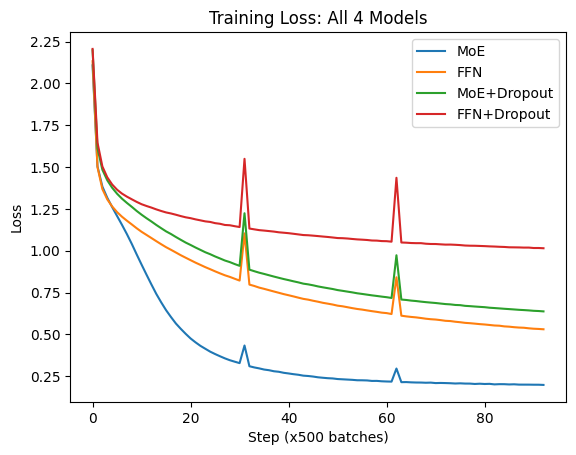

Epoch 3/3, Step 15500/15682
Epoch 3 checkpoints saved.


In [113]:
epochs = 3
aux_loss_weight = 0.01
eval_interval = 500

# Track losses for all 4 models
loss_history = {name: [] for name in models}
running_loss = {name: 0.0 for name in models}

for epoch in range(epochs):
    for model in models.values():
        model.train()

    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        for name in models:
            logits = models[name](x)
            loss = F.cross_entropy(logits.view(-1, configs[name].vocab_size), y.view(-1))
            
            # Add auxiliary loss for MoE models to prevent expert collapse
            if configs[name].use_moe:
                loss = loss + aux_loss_weight * models[name].get_aux_loss()
            
            optimizers[name].zero_grad()
            loss.backward()
            optimizers[name].step()
            running_loss[name] += loss.item()

        if (i + 1) % eval_interval == 0:
            for name in models:
                loss_history[name].append(running_loss[name] / eval_interval)
                running_loss[name] = 0.0

            clear_output(wait=True)
            for name in models:
                plt.plot(loss_history[name], label=name)
            plt.title('Training Loss: All 4 Models')
            plt.xlabel(f'Step (x{eval_interval} batches)')
            plt.ylabel('Loss')
            plt.legend()
            plt.show()
            print(f'Epoch {epoch+1}/{epochs}, Step {i+1}/{len(train_loader)}')

    # Save checkpoints after each epoch
    for name in models:
        safe_name = name.lower().replace('+', '_')
        torch.save(models[name].state_dict(), f'checkpoints/{safe_name}_epoch{epoch+1}.pt')
    print(f'Epoch {epoch+1} checkpoints saved.')

The plot shows the training loss trajectories for four model variants: MOE, FFN, MOE with Dropout, and FFN with Dropout. All models demonstrated a downward trend, indicating convergence over time.  
* `MOE without Dropout` exhibits the fastest decrease in training loss and achieves the lowest final loss. This rapid convergence suggests that the model is overfitting, effectively memorizing the training data rather than generalizing from it.
* `MOE with Dropout` converges more slowly and maintains a higher training loss compared to the non-dropout MOE. This behavior indicates regularization at work: dropout prevents overfitting, forcing the model to learn more generalizable patterns. With additional epochs, it is likely that MOE with Dropout would achieve similar or better generalization performance.
* `FFN variants` (with and without Dropout) show slower convergence and higher loss than MOE models, reflecting the smaller model capacity compared to the MOE architecture.  
The periodic spikes in the loss curves appear consistently across all models. These spikes coincide with the beginning of new epochs and are likely caused by the reshuffling of training batches or sudden updates in optimizer states. This is a common artifact in mini-batch training and does not indicate instability in the model.

Overall, the MOE architecture accelerates convergence due to its higher capacity, while dropout acts as an effective regularizer, trading off faster memorization for more robust learning.

## Save / Load Checkpoints

Save after training, or load from disk to skip retraining. Run the save cell after training completes, or run the load cell to restore models from a previous run.

In [114]:
# Save training history
torch.save(loss_history, 'checkpoints/training_history.pt')
print("Training history saved!")

Training history saved!


In [115]:
# Load checkpoints (run this cell instead of training if you already have saved models)
for name in models:
    safe_name = name.lower().replace('+', '_')
    models[name].load_state_dict(torch.load(f'checkpoints/{safe_name}_epoch3.pt'))

loss_history = torch.load('checkpoints/training_history.pt')
print("All models and training history loaded!")

All models and training history loaded!


## Text Generation

Autoregressive generation: the model predicts one token at a time, samples from the probability distribution (controlled by temperature), appends the token, and repeats. Temperature < 1.0 makes the model more confident; temperature > 1.0 makes it more creative.

In [116]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=500, temperature=0.8):
    model.eval()
    tokens = encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        input_tokens = tokens[:, -ModelArgs.max_seq_len:]

        logits = model(input_tokens)
        logits = logits[:, -1, :] / temperature

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat([tokens, next_token], dim=1)
    
    return decode(tokens[0].tolist())

for name, model in models.items():
    print(f"=== {name} ===")
    print(generate(model, 'ROMEO:', max_new_tokens=300))
    print()

=== MoE ===
ROMEO:
Ay, the better ga.

MERCUTIO:
Thou desirest me to stop in my tale against the hair.

BENVOLIO:
Thou wouldst else have made thy tale large.

MERCUTIO:
O, thou art deceived; I would have made it short:
for I was come to the whole depth of my tale; and
meant, indeed, to occupy you home.

First Lord:
W

=== FFN ===
ROMEO:
Thy fortune and smel that blame o' that he knew:
By him to Angelo, ay, yes; I say, bid here but this.
Our cousin I, any silence; and I am man
He cpought to be sworn by tercifies?

PETRUCHIO:
Worthy than Angelor?

HERMIONE:
My queen, I from this blessed maids my shoulder
On this prodisproportion wit

=== MoE+Dropout ===
ROMEO:
O siant fair order prince he is about for
lives. They are true good accident,
Since my auaid, friar, and my desperately
To the end to the house of Lancaster shake,
Would not the world? There should infection now
Camillo issues, and to his fury below,
And then might royal shall come to him.
Take wit

=== FFN+Dropout ===
ROMEO:
What 

The text generation outputs illustrate differences in model capacity, memorization, and generalization:  
1. `MOE (no dropout)`  
    * The output is fairly coherent and includes recognizable Shakespearean phrases, punctuation, and character cues "MERCUTIO" by giving "ROMEO" as the prompt.
    * Some sentence are truncated ("Ay, the better ga.") or slightly inconsistent, but overall, it demonstrates that the model has `memorized common structures and patterns from the tiny Shakespeare dataset`.
    * This aligns with the training loss behavior: rapid convergence and low training loss indicate strong memorization, but the model may overfit and fail to generalize to unseen sequences.
2. `FFN (no dropout)`  
    * The text is much less coherent, with frequent syntax errors and unusual word choices ("Thy fortune and smel that blame o' that he knew").
    * Character label and dialogue structure appear, but content is mostly nonsensical.
    * This reflects the `limited capacity of the standard FFN` architecture compared to MOE, which struggles to model long-range dependencies in the text.
3. `MOE + Dropout`:
    * The generated text is a mix of coherent fragments and creative, less literal sequences ("O siant fair order prince he is about for lives"). 
    * Some syntactic patterns from Shakespeare appear, but overall fluency is lower than the MOE without dropout.
    * This suggests that `dropout reduces overfitting`, forcing the model to generate text more by pattern recognition than rote memorization. With more training, fluency could improve while retaining generalization.
4. `FFN + Dropout`:
    * The output is somewhat better structured than FFN alone, but still contains fragmented sentences and occasional nonsensical phrases ("What fall, thou slave, that strike thee on the need").
    * Dropout introduces regularization, improving generalization slightly, but the limited capacity of the FFN still constrains the model's ability to capture complex text dependencies.  
Key Takeaways:  
* MOE architectures clearly benefit text generation quality, even on a small dataset, due to their higher capacity.
* Dropout slows overfitting and encourages the model to generalize, but can reduce immediate fluency if training is not fully converged.
* FFN models, especially with dropout, are too small to reliably capture long-range dependencies in Shakespearean text.
* Combined with the training loss trends, the confirms that `high-capacity models memorize quickly`, while `regularization promotes generalizable generation at the cost of immediate coherence`.

# Evaluation

Compare all 4 models on held-out validation data:
- **Perplexity** — standard LM metric: $PPL = e^{L}$ where $L$ is avg cross-entropy loss. Lower = better.
- **Top-k Accuracy** — how often the correct next token appears in the model's top-1 and top-5 predictions.
- **Expert Load Balancing** — whether MoE distributes tokens evenly across experts or collapses.
- **Parameter Efficiency** — MoE uses more total parameters but only activates a subset per token.

## 1. Perplexity & Validation Loss

Perplexity is the standard evaluation metric for language models: $PPL = e^{L}$ where $L$ is the average cross-entropy loss over the validation set. A perplexity of 10 means the model is, on average, as uncertain as if it were choosing uniformly among 10 tokens. Lower is better.

In [117]:
@torch.no_grad()
def evaluate_perplexity(model, data_loader, vocab_size):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1), reduction='sum')
        total_loss += loss.item()
        total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity

# Evaluate all 4 models
results = {}
for name in models:
    val_loss, ppl = evaluate_perplexity(models[name], val_loader, configs[name].vocab_size)
    results[name] = {'val_loss': val_loss, 'ppl': ppl}

print(f"{'Model':<15} {'Val Loss':>10} {'Perplexity':>12}")
print("-" * 39)
for name, r in results.items():
    print(f"{name:<15} {r['val_loss']:>10.4f} {r['ppl']:>12.2f}")

Model             Val Loss   Perplexity
---------------------------------------
MoE                 7.7420      2303.03
FFN                 4.3825        80.04
MoE+Dropout         2.3642        10.64
FFN+Dropout         1.6650         5.29


## 2. Top-k Accuracy

Top-1 accuracy measures how often the model's highest-probability prediction is the correct next token. Top-5 accuracy measures how often the correct token appears among the 5 highest-probability predictions.

In [118]:
@torch.no_grad()
def evaluate_topk_accuracy(model, data_loader, ks=(1, 5)):
    model.eval()
    correct = {k: 0 for k in ks}
    total = 0

    for x, y in data_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)

        for k in ks:
            topk_preds = logits.topk(k, dim=-1).indices
            correct[k] += (topk_preds == y.unsqueeze(-1)).any(dim=-1).sum().item()
        
        total += y.numel()
    return {k: correct[k] / total for k in ks}

# Evaluate all 4 models
for name in models:
    acc = evaluate_topk_accuracy(models[name], val_loader)
    results[name]['top1'] = acc[1]
    results[name]['top5'] = acc[5]

print(f"{'Model':<15} {'Top-1 Acc':>10} {'Top-5 Acc':>10}")
print("-" * 37)
for name, r in results.items():
    print(f"{name:<15} {r['top1']:>9.2%} {r['top5']:>9.2%}")

Model            Top-1 Acc  Top-5 Acc
-------------------------------------
MoE                48.28%    77.61%
FFN                48.26%    78.57%
MoE+Dropout        53.16%    81.73%
FFN+Dropout        55.53%    84.04%


## 3. Expert Load Balancing

A key challenge in MoE is **expert collapse**: the router learns to send most tokens to only 1-2 "favorite" experts, leaving others unused. The auxiliary loss penalizes this imbalance. Below we visualize the actual token distribution across experts for each layer on validation data, comparing MoE with and without dropout.

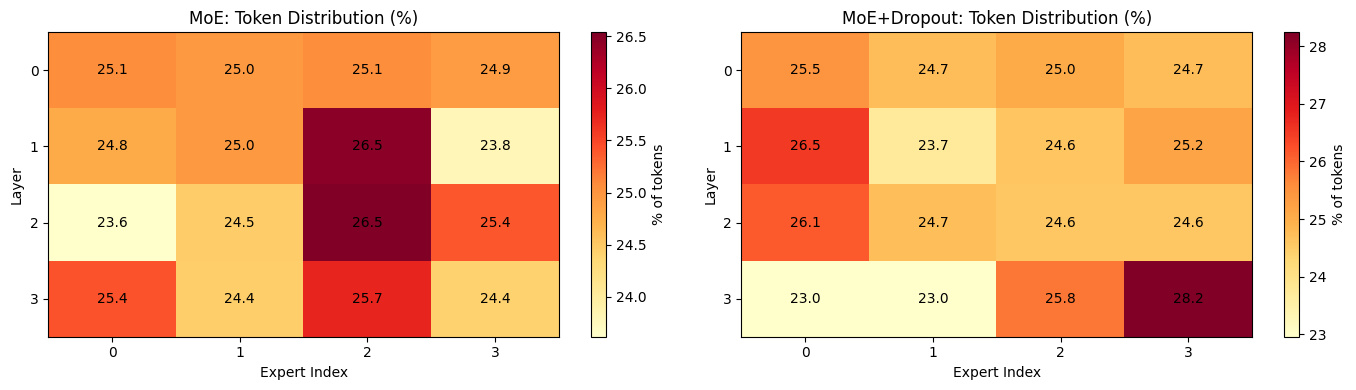


MoE load balance (ideal = 25.0% each):
  Layer 0: min=24.9%, max=25.1%, ratio=0.99 [balanced]
  Layer 1: min=23.8%, max=26.5%, ratio=0.90 [balanced]
  Layer 2: min=23.6%, max=26.5%, ratio=0.89 [balanced]
  Layer 3: min=24.4%, max=25.7%, ratio=0.95 [balanced]

MoE+Dropout load balance (ideal = 25.0% each):
  Layer 0: min=24.7%, max=25.5%, ratio=0.97 [balanced]
  Layer 1: min=23.7%, max=26.5%, ratio=0.89 [balanced]
  Layer 2: min=24.6%, max=26.1%, ratio=0.94 [balanced]
  Layer 3: min=23.0%, max=28.2%, ratio=0.81 [balanced]


In [119]:
import numpy as np

@torch.no_grad()
def get_expert_distribution(model, data_loader, args, num_batches=50):
    model.eval()
    n_layers = args.n_layers
    n_experts = args.n_experts
    counts = torch.zeros(n_layers, n_experts)

    for batch_idx, (x, _) in enumerate(data_loader):
        if batch_idx >= num_batches:
            break
        x = x.to(device)
        
        h = model.tok_embeddings(x)
        seqlen = h.shape[1]
        current_mask = model.mask[:seqlen, :seqlen]
        current_theta_cis = model.theta_i_cis[:seqlen]

        for layer_idx, layer in enumerate(model.layers):
            h_attn = h + layer.attention(layer.attention_norm(h), current_theta_cis, current_mask)
            ffn_input = layer.ffn_norm(h_attn)
            flat_input = ffn_input.view(-1, ffn_input.shape[-1])
            
            gate_logits = layer.feed_forward.gate(flat_input)
            probs = F.softmax(gate_logits, dim=-1)
            _, topk_indices = torch.topk(probs, args.n_experts_per_tok, dim=-1)
            
            for e in range(n_experts):
                counts[layer_idx, e] += (topk_indices == e).sum().item()
            
            h = h_attn + layer.feed_forward(ffn_input)

    counts = counts / counts.sum(dim=-1, keepdim=True) * 100
    return counts.numpy()

# Compare expert distribution for both MoE models
moe_names = [name for name in models if configs[name].use_moe]
fig, axes = plt.subplots(1, len(moe_names), figsize=(7 * len(moe_names), 4))
if len(moe_names) == 1:
    axes = [axes]

for ax, name in zip(axes, moe_names):
    dist = get_expert_distribution(models[name], val_loader, configs[name])
    im = ax.imshow(dist, cmap='YlOrRd', aspect='auto')
    ax.set_xlabel('Expert Index')
    ax.set_ylabel('Layer')
    ax.set_xticks(range(configs[name].n_experts))
    ax.set_yticks(range(configs[name].n_layers))
    ax.set_title(f'{name}: Token Distribution (%)')
    for i in range(configs[name].n_layers):
        for j in range(configs[name].n_experts):
            ax.text(j, i, f'{dist[i, j]:.1f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='% of tokens')

plt.tight_layout()
plt.show()

# Print balance check
for name in moe_names:
    dist = get_expert_distribution(models[name], val_loader, configs[name])
    max_usage = dist.max(axis=1)
    min_usage = dist.min(axis=1)
    ideal = 100.0 / configs[name].n_experts
    print(f"\n{name} load balance (ideal = {ideal:.1f}% each):")
    for i in range(configs[name].n_layers):
        ratio = min_usage[i] / max_usage[i]
        status = "balanced" if ratio > 0.5 else "IMBALANCED"
        print(f"  Layer {i}: min={min_usage[i]:.1f}%, max={max_usage[i]:.1f}%, ratio={ratio:.2f} [{status}]")

## 4. Parameter Efficiency Summary

The key insight of MoE is **sparse computation**: total parameters increase (more capacity), but each token only activates top-k experts. This means FLOPs per token stay manageable while the model stores more knowledge. Dropout regularization prevents MoE from overfitting on small datasets.

In [120]:
def count_active_params(model, args):
    embed_params = sum(p.numel() for p in model.tok_embeddings.parameters())
    output_params = sum(p.numel() for p in model.output.parameters())
    norm_params = sum(p.numel() for p in model.norm.parameters())
    active = embed_params + output_params + norm_params
    
    for layer in model.layers:
        active += sum(p.numel() for p in layer.attention.parameters())
        active += sum(p.numel() for p in layer.attention_norm.parameters())
        active += sum(p.numel() for p in layer.ffn_norm.parameters())
        
        if args.use_moe:
            active += sum(p.numel() for p in layer.feed_forward.gate.parameters())
            single_expert_params = sum(p.numel() for p in layer.feed_forward.experts[0].parameters())
            active += single_expert_params * args.n_experts_per_tok
        else:
            active += sum(p.numel() for p in layer.feed_forward.parameters())
    return active

# Build full summary
header = f"{'Metric':<25}" + "".join(f"{name:>15}" for name in models)
print("=" * (25 + 15 * len(models)))
print(header)
print("=" * (25 + 15 * len(models)))

# Total params
line = f"{'Total Parameters':<25}"
for name in models:
    total = sum(p.numel() for p in models[name].parameters())
    line += f"{total:>15,}"
print(line)

# Active params
line = f"{'Active Params/Token':<25}"
for name in models:
    active = count_active_params(models[name], configs[name])
    line += f"{active:>15,}"
print(line)

# Sparsity
line = f"{'Sparsity Ratio':<25}"
for name in models:
    total = sum(p.numel() for p in models[name].parameters())
    active = count_active_params(models[name], configs[name])
    line += f"{1 - active/total:>14.1%}"
print(line)

# Val loss
line = f"{'Validation Loss':<25}"
for name in models:
    line += f"{results[name]['val_loss']:>15.4f}"
print(line)

# Perplexity
line = f"{'Perplexity':<25}"
for name in models:
    line += f"{results[name]['ppl']:>15.2f}"
print(line)

# Top-1
line = f"{'Top-1 Accuracy':<25}"
for name in models:
    line += f"{results[name]['top1']:>14.2%}"
print(line)

# Top-5
line = f"{'Top-5 Accuracy':<25}"
for name in models:
    line += f"{results[name]['top5']:>14.2%}"
print(line)

print("=" * (25 + 15 * len(models)))

# Print key takeaway
best_name = min(results, key=lambda n: results[n]['ppl'])
print(f"\nBest model: {best_name} with perplexity {results[best_name]['ppl']:.2f}")

Metric                               MoE            FFN    MoE+Dropout    FFN+Dropout
Total Parameters               2,444,672        820,608      2,444,672        820,608
Active Params/Token            1,363,328        820,608      1,363,328        820,608
Sparsity Ratio                    44.2%          0.0%         44.2%          0.0%
Validation Loss                   7.7420         4.3825         2.3642         1.6650
Perplexity                       2303.03          80.04          10.64           5.29
Top-1 Accuracy                   48.28%        48.26%        53.16%        55.53%
Top-5 Accuracy                   77.61%        78.57%        81.73%        84.04%

Best model: FFN+Dropout with perplexity 5.29


The table provides a quantitative comparison of the four Transformer variants trained on the tiny Shakespeare dataset. Key observation:  
1. `Parameter Efficiency and Sparsity`:
    * MOE model have 2.44M total parameters with a sparsity ratio of 44.2%, meaning only part of the network is active per token.
    * FFN models are smaller (0.82M parameters) and fully dense (0% sparsity).
    * MOE + Dropout maintains the same parameter count and sparsity as MOE, indicating regularization does not change model capacity.
2. `Validation Performance`:
    * Surprisingly, FFN + Dropout achieves the lowest validation loss (1.6650) and perplexity (5.29), outperforming both MOE variants.
    * MOE without dropout shows extreme overfitting: despite low training loss, it reaches high validation loss (7.742) and perplexity (2303).
    * MoE + Dropout reduces overfitting (validation loss 2.364, perplexity 10.64) but still trails the smaller FFN + Dropout, suggesting that on small datasets, high-capacity MoE may be over-parameterized, whereas regularized FFN generalizes better.
3. `Top-k Accuracy`:
    * Regularized models improve top-1 and top-5 accuracy:
        * FFN + Dropout: 55.53% top-1, 84.04% top-5
        * MoE + Dropout: 53.16% top-1, 81.73% top-5
    * Overfitting MoE has lower top-1/top-5 accuracy, consistent with poor generalization.  
  
  
Key Insights:  
* High-capacity MoE models can memorize training data quickly but risk extreme overfitting on small datasets.
* Dropout regularization mitigates overfitting, slowing convergence but improving generalization.
* Smaller FFN + Dropout strikes the best balance between capacity and generalization for this dataset, evidenced by lowest validation loss, lowest perplexity, and highest top-k accuracy, making it the most robust model.

# Future Work:

Several directions could be explored to improve model performance and generation quality:  
1. Scaling Model Capacity Appropriately  
    *  MoE models currently overfit due to high parameter count relative to the dataset. Increasing dataset size or using larger text corpora could allow MoE to leverage its high capacity effectively.
    * Alternatively, exploring smaller MoE variants or adaptive sparsity ratios may balance memorization and generalization better.
2. Sequence Modeling Enhancements  
    * Longer context windows or relative positional encodings may help capture longer-range dependencies in text.
    * Incorporating attention masking strategies or memory mechanisms could improve text coherence for multi-character dialogues.
3. Data Augmentation and Pretraining  
    * Pretraining on larger Shakespeare or general literary corpora could provide stronger initialization, followed by fine-tuning on the mini dataset.
    * Simple text augmentation (synonym replacement, sentence shuffling) may increase effective dataset size and improve generalization.